# Causal Factor Analysis: Momentum vs Reversal

What factors predict whether a news event will hit the synthetic box (momentum) or opposite data point (reversal) first?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_parquet('data/sweep_analysis_results.parquet')

# Filter to resolved trades only
df = df[df['first_target_hit'].notna()].copy()
print(f"Resolved trades: {len(df)}")

# Create binary target: 1 = momentum (box first), 0 = reversal (opposite first)
df['target'] = (df['first_target_hit'] == 'box').astype(int)
print(f"Momentum: {df['target'].sum()} ({df['target'].mean()*100:.1f}%)")
print(f"Reversal: {(1-df['target']).sum()} ({(1-df['target'].mean())*100:.1f}%)")

# Show available features
print("\nAvailable columns:")
print(df.columns.tolist())

Resolved trades: 1335
Momentum: 682 (51.1%)
Reversal: 653 (48.9%)

Available columns:
['event_type', 'event_datetime', 'release_time', 'data_high', 'data_low', 'range', 'range_pct', 'first_sweep', 'time_to_first_sweep', 'opposite_swept', 'time_to_opposite_sweep', 'synthetic_box_breached', 'first_target_hit', 'mae_before_reversal', 'pre_candle_range_pct', 'pre_candle_volume', 'dist_from_midnight_open_pct', 'dist_from_6pm_open_pct', 'gap_6pm_pct', 'gap_6pm_direction', 'release_volume', 'target']


## 1. Feature Engineering

In [2]:
# Create features dataframe
features = pd.DataFrame()

# === CATEGORICAL FEATURES ===
# Event type
le_event = LabelEncoder()
features['event_type_encoded'] = le_event.fit_transform(df['event_type'])

# Release time
le_time = LabelEncoder()
features['release_time_encoded'] = le_time.fit_transform(df['release_time'])

# First sweep direction (1 = high, 0 = low)
features['first_sweep_high'] = (df['first_sweep'] == 'high').astype(int)

# Gap direction (1 = up, 0 = down, -1 = flat/missing)
gap_dir_map = {'up': 1, 'down': 0, 'flat': -1}
features['gap_direction_encoded'] = df['gap_6pm_direction'].map(gap_dir_map).fillna(-1).astype(int)

# === CONTINUOUS FEATURES ===
# Release candle metrics
features['range_pct'] = df['range_pct']
features['release_volume'] = df['release_volume']

# Pre-news candle (8:29)
features['pre_candle_range_pct'] = df['pre_candle_range_pct'].fillna(0)
features['pre_candle_volume'] = df['pre_candle_volume'].fillna(0)

# Session context
features['dist_from_midnight_open_pct'] = df['dist_from_midnight_open_pct'].fillna(0)
features['dist_from_6pm_open_pct'] = df['dist_from_6pm_open_pct'].fillna(0)
features['gap_6pm_pct'] = df['gap_6pm_pct'].fillna(0)

# Time to first sweep
features['time_to_first_sweep'] = df['time_to_first_sweep']

# Target
y = df['target']

print(f"Total features: {len(features.columns)}")
print("\nFeatures:")
for col in features.columns:
    print(f"  • {col}")

features.describe()

Total features: 12

Features:
  • event_type_encoded
  • release_time_encoded
  • first_sweep_high
  • gap_direction_encoded
  • range_pct
  • release_volume
  • pre_candle_range_pct
  • pre_candle_volume
  • dist_from_midnight_open_pct
  • dist_from_6pm_open_pct
  • gap_6pm_pct
  • time_to_first_sweep


,event_type_encoded,release_time_encoded,first_sweep_high,gap_direction_encoded,range_pct,release_volume,pre_candle_range_pct,pre_candle_volume,dist_from_midnight_open_pct,dist_from_6pm_open_pct,gap_6pm_pct,time_to_first_sweep
count,1335.000000,1335.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000,1272.000000
mean,16.639700,5.845693,0.538522,0.345912,0.351215,3092.780660,0.062342,275.503145,0.041612,0.098064,0.051820,4.380503
std,9.855162,2.723683,0.498710,0.648061,0.353968,2041.995232,0.094444,259.605111,0.674623,0.796934,0.104305,11.126193
min,0.000000,0.000000,0.000000,-1.000000,0.016338,125.000000,0.004799,22.000000,-3.322016,-3.302000,0.000000,1.000000
25%,7.000000,4.000000,0.000000,0.000000,0.141113,1428.000000,0.027391,145.000000,-0.255673,-0.251449,0.006234,1.000000
50%,17.000000,4.000000,1.000000,0.000000,0.246698,2768.500000,0.039971,211.000000,0.068135,0.103685,0.022264,1.000000
75%,25.000000,8.000000,1.000000,1.000000,0.440773,4158.500000,0.067471,316.750000,0.309391,0.430641,0.050665,3.000000
max,31.000000,12.000000,1.000000,1.000000,3.502747,11617.000000,1.362315,2923.000000,11.501602,9.623844,1.563266,101.000000


## 2. Feature Importance (Random Forest)

Random Forest CV Accuracy: 50.0% (+/- 5.7%)
Baseline (always predict majority): 51.1%


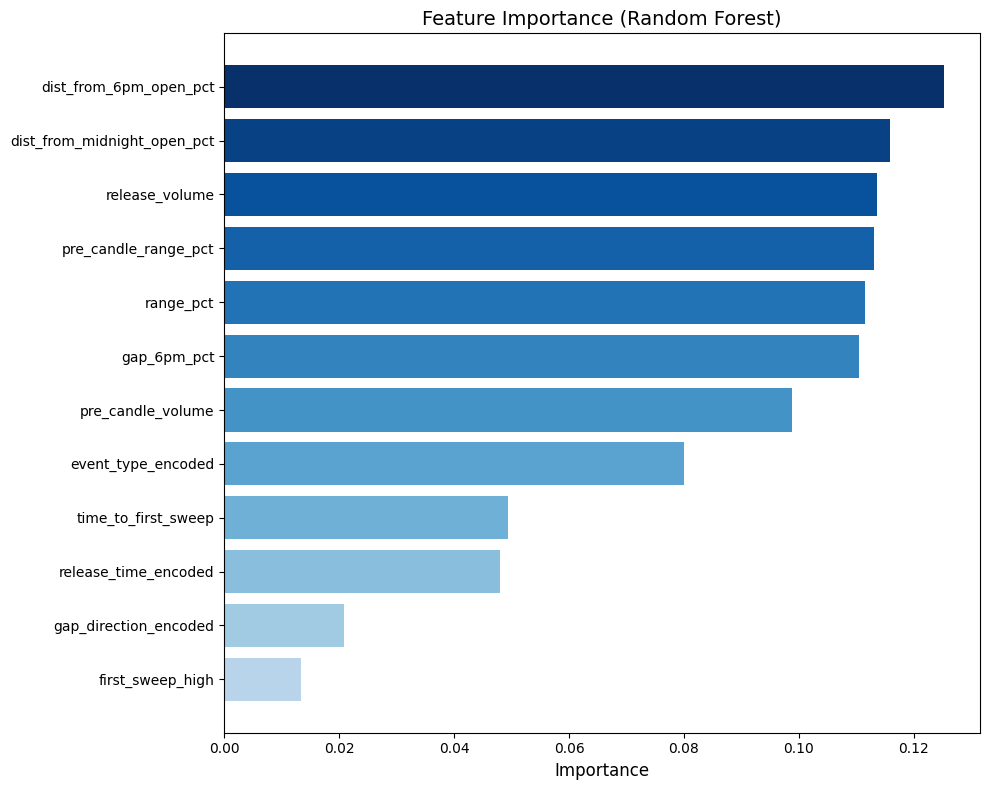


Feature Importance Ranking:
                    feature  importance
     dist_from_6pm_open_pct    0.125251
dist_from_midnight_open_pct    0.115810
             release_volume    0.113517
       pre_candle_range_pct    0.113109
                  range_pct    0.111461
                gap_6pm_pct    0.110468
          pre_candle_volume    0.098734
         event_type_encoded    0.080049
        time_to_first_sweep    0.049373
       release_time_encoded    0.048022
      gap_direction_encoded    0.020817
           first_sweep_high    0.013389


In [3]:
# Use all features
X = features.copy()

# Train random forest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Cross-validation
scores = cross_val_score(rf, X, y, cv=5)
print(f"Random Forest CV Accuracy: {scores.mean()*100:.1f}% (+/- {scores.std()*100:.1f}%)")
print(f"Baseline (always predict majority): {max(y.mean(), 1-y.mean())*100:.1f}%")

# Feature importance
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Blues(np.linspace(0.3, 1, len(importance)))
ax.barh(importance['feature'], importance['importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance (Random Forest)', fontsize=14)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nFeature Importance Ranking:")
print(importance.sort_values('importance', ascending=False).to_string(index=False))

## 3. Decision Tree (Interpretable Rules)

In [4]:
# Train decision tree with limited depth for interpretability
tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=25, random_state=42)
tree.fit(X, y)

# Cross-validation score
tree_scores = cross_val_score(tree, X, y, cv=5)
print(f"Decision Tree CV Accuracy: {tree_scores.mean()*100:.1f}% (+/- {tree_scores.std()*100:.1f}%)")

Decision Tree CV Accuracy: 51.4% (+/- 2.9%)


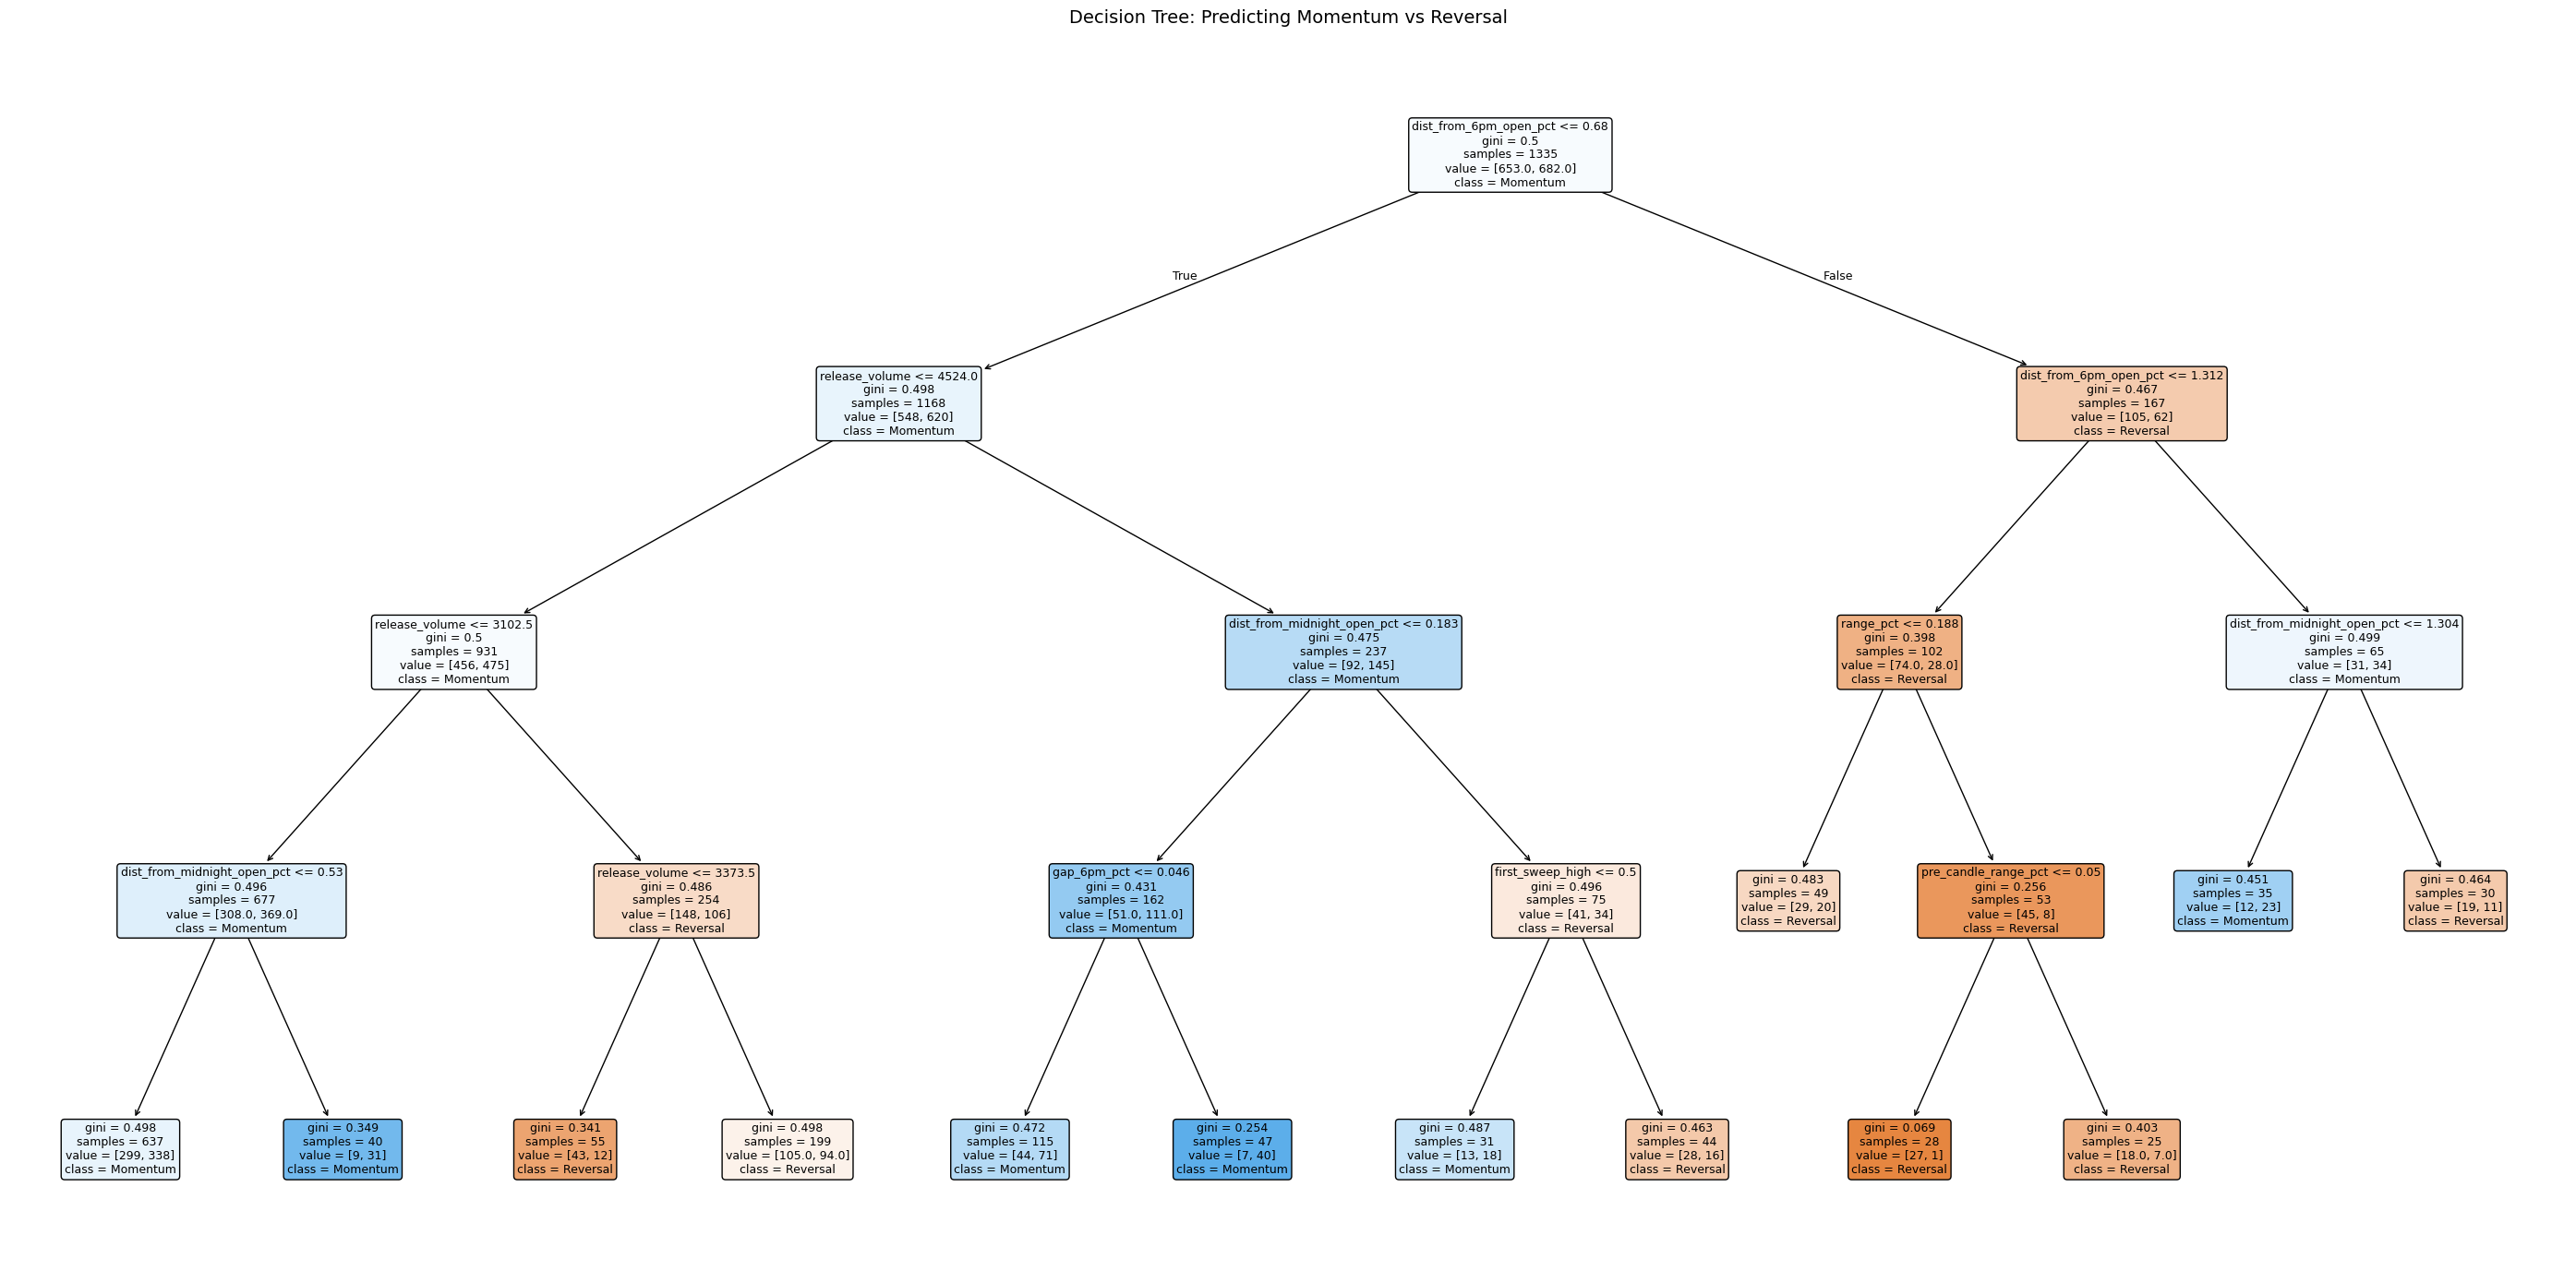

In [5]:
# Visualize the tree
fig, ax = plt.subplots(figsize=(28, 14))
plot_tree(tree, 
          feature_names=list(X.columns),
          class_names=['Reversal', 'Momentum'],
          filled=True, 
          rounded=True,
          fontsize=9,
          ax=ax)
plt.title('Decision Tree: Predicting Momentum vs Reversal', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Logistic Regression (Direction of Effects)

In [6]:
# Standardize for interpretable coefficients
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Logistic regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_scaled, y)

# Coefficients (positive = more momentum, negative = more reversal)
coefs = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient')

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if c < 0 else '#e74c3c' for c in coefs['coefficient']]
ax.barh(coefs['feature'], coefs['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coefficient (Standardized)', fontsize=12)
ax.set_title('Logistic Regression: Effect Direction\n← Favors REVERSAL | Favors MOMENTUM →', fontsize=14)
plt.tight_layout()
plt.show()

print("\nLogistic Regression Coefficients:")
print("Positive = pushes toward MOMENTUM")
print("Negative = pushes toward REVERSAL")
print()
print(coefs.to_string(index=False))

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 5. Correlation Analysis

In [7]:
# Correlation of numeric features with target
numeric_features = ['range_pct', 'release_volume', 'pre_candle_range_pct', 'pre_candle_volume',
                    'dist_from_midnight_open_pct', 'dist_from_6pm_open_pct', 'gap_6pm_pct',
                    'time_to_first_sweep', 'first_sweep_high']

correlations = pd.DataFrame({
    'feature': numeric_features,
    'correlation': [features[f].corr(y) for f in numeric_features]
}).sort_values('correlation')

print("Correlation with MOMENTUM outcome:")
print("Positive = associated with momentum")
print("Negative = associated with reversal")
print()
print(correlations.to_string(index=False))

Correlation with MOMENTUM outcome:
Positive = associated with momentum
Negative = associated with reversal

                    feature  correlation
                gap_6pm_pct    -0.068211
          pre_candle_volume    -0.065550
           first_sweep_high    -0.057872
                  range_pct    -0.049912
     dist_from_6pm_open_pct    -0.030644
       pre_candle_range_pct    -0.023643
             release_volume    -0.015970
dist_from_midnight_open_pct    -0.010183
        time_to_first_sweep     0.091559


## 6. Event Type Deep Dive

In [8]:
# Event type stats
event_stats = df.groupby('event_type').agg(
    n=('target', 'count'),
    momentum_rate=('target', 'mean'),
    avg_range=('range_pct', 'mean'),
    avg_volume=('release_volume', 'mean'),
    avg_dist_midnight=('dist_from_midnight_open_pct', 'mean'),
).reset_index()

event_stats['reversal_rate'] = 1 - event_stats['momentum_rate']
event_stats['edge'] = abs(event_stats['momentum_rate'] - 0.5) * 100
event_stats['direction'] = event_stats['momentum_rate'].apply(
    lambda x: 'MOMENTUM' if x > 0.5 else 'REVERSAL')

event_stats = event_stats.sort_values('edge', ascending=False)

print("Events ranked by edge:")
print(event_stats[['event_type', 'n', 'momentum_rate', 'edge', 'direction']].to_string(index=False))

Events ranked by edge:
                         event_type   n  momentum_rate      edge direction
  US Revised UoM Consumer Sentiment  11       0.090909 40.909091  REVERSAL
                   US Final GDP q/q  11       0.727273 22.727273  MOMENTUM
           US FOMC Press Conference  42       0.714286 21.428571  MOMENTUM
   US Prelim UoM Consumer Sentiment  33       0.666667 16.666667  MOMENTUM
                US ISM Services PMI  53       0.660377 16.037736  MOMENTUM
                    US Core PPI m/m  32       0.656250 15.625000  MOMENTUM
                  US Prelim GDP q/q  18       0.388889 11.111111  REVERSAL
      US Fed Chair Powell Testifies  33       0.606061 10.606061  MOMENTUM
       US Employment Cost Index q/q  10       0.600000 10.000000  MOMENTUM
           US ISM Manufacturing PMI  60       0.400000 10.000000  REVERSAL
                 US Advance GDP q/q  20       0.400000 10.000000  REVERSAL
       US FOMC Economic Projections  20       0.600000 10.000000  MOMENTUM
  

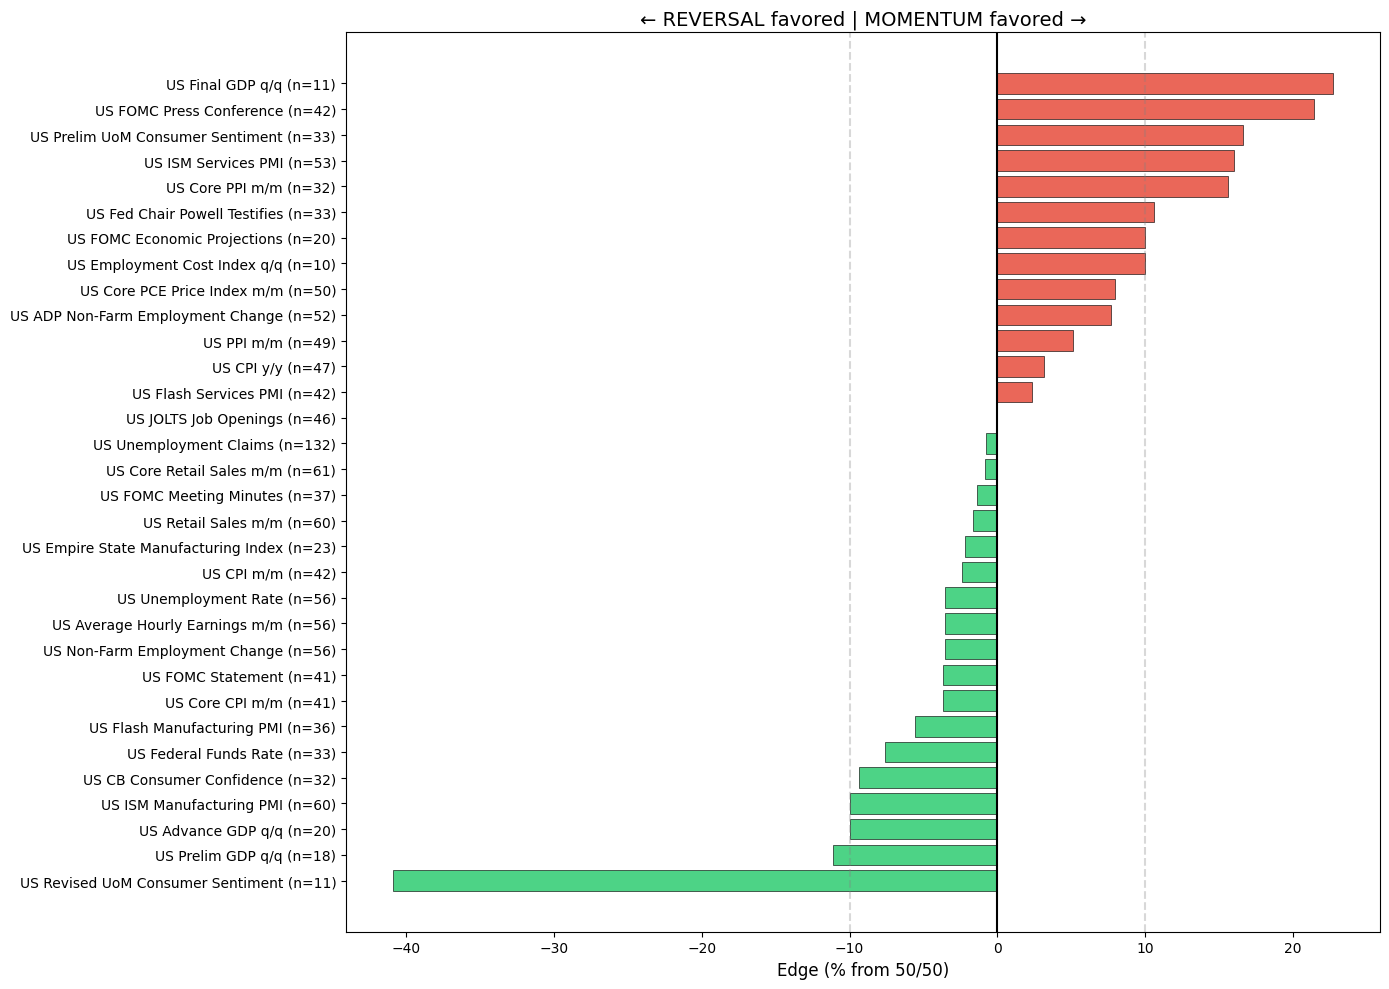

In [9]:
# Visualize event edges
fig, ax = plt.subplots(figsize=(14, 10))

event_stats_sorted = event_stats.sort_values('momentum_rate')
colors = ['#2ecc71' if x < 0.5 else '#e74c3c' for x in event_stats_sorted['momentum_rate']]

ax.barh(range(len(event_stats_sorted)), 
        event_stats_sorted['momentum_rate'] * 100 - 50,
        color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)

ax.set_yticks(range(len(event_stats_sorted)))
ax.set_yticklabels([f"{e} (n={n})" for e, n in 
                    zip(event_stats_sorted['event_type'], event_stats_sorted['n'])])
ax.axvline(0, color='black', linewidth=1.5)
ax.axvline(-10, color='gray', linestyle='--', alpha=0.3)
ax.axvline(10, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Edge (% from 50/50)', fontsize=12)
ax.set_title('← REVERSAL favored | MOMENTUM favored →', fontsize=14)

plt.tight_layout()
plt.savefig('event_edge.png', dpi=150)
plt.show()

## 7. Session Context Analysis

In [10]:
# Does gap direction matter?
gap_stats = df.groupby('gap_6pm_direction').agg(
    n=('target', 'count'),
    momentum_rate=('target', 'mean'),
).reset_index()
print("Gap Direction (6pm):")
print(gap_stats.to_string(index=False))

print("\n" + "="*50)

# Distance from opens - quartile analysis
df['midnight_dist_quartile'] = pd.qcut(df['dist_from_midnight_open_pct'].fillna(0), 4, 
                                        labels=['Q1 (far below)', 'Q2', 'Q3', 'Q4 (far above)'])

midnight_stats = df.groupby('midnight_dist_quartile').agg(
    n=('target', 'count'),
    momentum_rate=('target', 'mean'),
).reset_index()
print("\nDistance from Midnight Open:")
print(midnight_stats.to_string(index=False))

Gap Direction (6pm):
gap_6pm_direction   n  momentum_rate
             down 605       0.474380
             flat  58       0.431034
               up 601       0.550749


Distance from Midnight Open:
midnight_dist_quartile   n  momentum_rate
        Q1 (far below) 334       0.494012
                    Q2 335       0.510448
                    Q3 333       0.537538
        Q4 (far above) 333       0.501502


## 8. Actionable Decision Rules

In [13]:
from sklearn.tree import export_text

# One-hot encode events for readable rules
event_dummies = pd.get_dummies(df['event_type'], prefix='event')
X_readable = pd.concat([event_dummies, 
                        features[['first_sweep_high', 'range_pct', 'release_volume',
                                  'dist_from_midnight_open_pct', 'gap_6pm_pct']]], axis=1)

tree_readable = DecisionTreeClassifier(max_depth=3, min_samples_leaf=40, random_state=42)
tree_readable.fit(X_readable, y)

print("Decision Rules:")
print(export_text(tree_readable, feature_names=list(X_readable.columns), max_depth=3))

ValueError: Number of labels=1335 does not match number of samples=1398

## 9. Key Findings Summary

In [14]:
print("="*70)
print("KEY FINDINGS")
print("="*70)

# Top importance features
print("\n📊 MOST PREDICTIVE FEATURES (Random Forest):")
for _, row in importance.sort_values('importance', ascending=False).head(5).iterrows():
    print(f"   • {row['feature']}: {row['importance']:.3f}")

# Top momentum events
print("\n🔴 MOMENTUM-FAVORING EVENTS (play the box):")
for _, row in event_stats[event_stats['direction'] == 'MOMENTUM'].head(5).iterrows():
    print(f"   • {row['event_type']}: {row['momentum_rate']*100:.0f}% momentum (n={row['n']})")

# Top reversal events
print("\n🟢 REVERSAL-FAVORING EVENTS (play the opposite):")
for _, row in event_stats[event_stats['direction'] == 'REVERSAL'].head(5).iterrows():
    print(f"   • {row['event_type']}: {row['reversal_rate']*100:.0f}% reversal (n={row['n']})")

# Session context insights
print("\n📈 SESSION CONTEXT INSIGHTS:")
for _, row in correlations.iterrows():
    if abs(row['correlation']) > 0.05:
        direction = '↑ momentum' if row['correlation'] > 0 else '↓ reversal'
        print(f"   • {row['feature']}: {row['correlation']:.3f} ({direction})")

KEY FINDINGS

📊 MOST PREDICTIVE FEATURES (Random Forest):
   • dist_from_6pm_open_pct: 0.125
   • dist_from_midnight_open_pct: 0.116
   • release_volume: 0.114
   • pre_candle_range_pct: 0.113
   • range_pct: 0.111

🔴 MOMENTUM-FAVORING EVENTS (play the box):
   • US Final GDP q/q: 73% momentum (n=11)
   • US FOMC Press Conference: 71% momentum (n=42)
   • US Prelim UoM Consumer Sentiment: 67% momentum (n=33)
   • US ISM Services PMI: 66% momentum (n=53)
   • US Core PPI m/m: 66% momentum (n=32)

🟢 REVERSAL-FAVORING EVENTS (play the opposite):
   • US Revised UoM Consumer Sentiment: 91% reversal (n=11)
   • US Prelim GDP q/q: 61% reversal (n=18)
   • US ISM Manufacturing PMI: 60% reversal (n=60)
   • US Advance GDP q/q: 60% reversal (n=20)
   • US CB Consumer Confidence: 59% reversal (n=32)

📈 SESSION CONTEXT INSIGHTS:
   • gap_6pm_pct: -0.068 (↓ reversal)
   • pre_candle_volume: -0.066 (↓ reversal)
   • first_sweep_high: -0.058 (↓ reversal)
   • time_to_first_sweep: 0.092 (↑ momentum)
